In [1]:
from pathlib import Path

import mne
import numpy as np
import pandas as pd
from autoreject import AutoReject
from pyprep.find_noisy_channels import NoisyChannels

In [2]:
EEG_RAW_DIR = Path().resolve().parent / 'data' / 'eeg-raw'
EEG_PROCESSED_DIR = Path().resolve().parent / 'data' / 'eeg-processed'

In [3]:
# Se seleccionan solamente los eventos de los bloques 3,4,6 y 7 correspondientes a 
# estímulos cuyas respuestas fueron correctas

def extraerCorrectas(eventos):
    pos=[]
    correctas=[]
    i=0
    j=0
    for i in range(len(eventos)):
        if eventos[i][2] == 12 and eventos[i+1][2]==108:
            pos.append(i)
        elif eventos[i][2] == 13 and eventos[i+1][2]==109:
            pos.append(i)
        elif eventos[i][2] == 14 and eventos[i+1][2]==110:
            pos.append(i)
        elif eventos[i][2] == 15 and eventos[i+1][2]==111:
            pos.append(i)
        elif eventos[i][2] == 16 and eventos[i+1][2]==112:
            pos.append(i)
        elif eventos[i][2] == 17 and eventos[i+1][2]==113:
            pos.append(i)
        elif eventos[i][2] == 18 and eventos[i+1][2]==114:
            pos.append(i)
        elif eventos[i][2] == 19 and eventos[i+1][2]==115:
            pos.append(i)
        elif eventos[i][2] == 24 and eventos[i+1][2]==120:
            pos.append(i)
        elif eventos[i][2] == 25 and eventos[i+1][2]==121:
            pos.append(i)
        elif eventos[i][2] == 26 and eventos[i+1][2]==122:
            pos.append(i)
        elif eventos[i][2] == 27 and eventos[i+1][2]==123:
            pos.append(i)    
        elif eventos[i][2] == 28 and eventos[i+1][2]==124:
            pos.append(i)
        elif eventos[i][2] == 29 and eventos[i+1][2]==125:
            pos.append(i)
        elif eventos[i][2] == 30 and eventos[i+1][2]==126:
            pos.append(i)
        elif eventos[i][2] == 31 and eventos[i+1][2]==127:
            pos.append(i)
    for j in range(len(pos)):
        x=int(pos[j])
        y=eventos[x]
        correctas.append(y)
    return correctas

In [4]:
# Primero eliminación e interpolación de canales malos, luego referenciación REST, 
# luego ICA, luego epoching, luego remoción épocas malas

def Preprocesamiento_REST_ICA_epoch(
    raw,
    decim=8,
    montage='biosemi64',
    h_freq=30,
    l_freq=0.5,
    tmax=2.0,
    threshold=0.5,
):
    # Montaje
    raw.set_montage(
        montage=mne.channels.make_standard_montage(kind=montage), 
        match_case=False
        )
    
    # Preparación de referenciación REST - modelo de cabeza
    raw.del_proj()
    sphere = mne.make_sphere_model(
        'auto', 
        'auto', 
        raw.info
        )
    
    src = mne.setup_volume_source_space(
        sphere=sphere, 
        exclude=30., 
        pos=5.
        )
    
    forward = mne.make_forward_solution(
        raw.info, 
        trans=None, 
        src=src, 
        bem=sphere
        )
    
    # Detección de canales ruidosos
        
    NC = NoisyChannels(
        raw, 
        do_detrend=True,
        ransac=True,
        random_state=1
        )
    
    NC.find_all_bads(ransac=False)
    bad_channels = NC.get_bads()
    
    # Interpolación de canales ruidosos
    raw.info["bads"] = NC.get_bads()
    raw.interpolate_bads(reset_bads=True, verbose=False)
    
    # Referenciación REST
    raw.set_eeg_reference(
        ref_channels='REST', 
        projection=False, 
        ch_type='auto', 
        forward=forward
        )
            
    # Cálculo de componentes independientes
    
    raw_ica = raw.copy()
    raw_ica.filter(
        l_freq=1.0, 
        h_freq=None
        )
    
    ica = mne.preprocessing.ICA(
        n_components=None, 
        random_state=1, 
        method='fastica'
        )
    
    ica.fit(raw_ica)
 
    # Detección de componentes oculares
    eog_indices, ___ = ica.find_bads_eog(raw, ch_name='FPZ')
     
    # Detección de componentes musculares
    muscle_indices, ___ = ica.find_bads_muscle(raw, threshold=threshold)
    
    # Eliminación de componentes
    ica.exclude = eog_indices + muscle_indices
    ica_bad_components = list(ica.exclude)
    ica.apply(raw, exclude=ica.exclude)
        
    # Epoching, selección de épocas de interés y submuestreo
    events = mne.find_events(raw, stim_channel='Status')
    event_id = [12, 13, 14, 15, 16, 17, 18, 19, 24, 25, 26, 27, 28, 29, 30, 31]

    # Aplicar un filtro de paso bajo antes de la decimación para evitar aliasing
    raw.filter(l_freq=l_freq, h_freq=h_freq)

    # Extraer solo las épocas de los eventos de interés
    epochs= mne.Epochs(
        raw, 
        events=events, 
        event_id=event_id, 
        tmin=-0.2, tmax=tmax, 
        baseline=(None,0), 
        picks=['eeg'], 
        preload=True, 
        decim=decim
        )
    
    # Reparación y eliminación de épocas malas
    ar = AutoReject(verbose = False, random_state = 1)
    ar.fit(epochs)
    epochs_clean, reject_log = ar.transform(epochs, return_log=True)
    bad_epochs = np.sum(reject_log.bad_epochs)
    
    print('Canales ruidosos: ',bad_channels)
    print('Componentes oculares: ',eog_indices)
    print('Componentes musculares: ',muscle_indices)
    print('Épocas rechazadas: ', bad_epochs)
        
    return epochs_clean, bad_channels, ica_bad_components, bad_epochs


In [5]:
def cargar_eeg(ruta=EEG_RAW_DIR):
    return sorted(ruta.glob('*.edf'))

# Procesamiento de todos los sujetos

In [6]:
eeg_paths = cargar_eeg()

log_processing = pd.DataFrame(
    columns=['Subject', 'Bad channels', 'Total bad channels', 'Bad ICA components',
    'Total bad ICA components', 'Total bad epochs']
    )

for eeg in range(len(eeg_paths)):
    raw = mne.io.read_raw_edf(eeg_paths[eeg], preload=True)
    epochs, bad_channels, ica_bad_components, bad_epochs = Preprocesamiento_REST_ICA_epoch(
        raw, threshold=0.9
        )

    # Guardar las épocas preprocesadas en formato .fif
    subject_id = eeg_paths[eeg].stem[:5]
    epochs.save(
        EEG_PROCESSED_DIR / (subject_id + '_epo.fif'), 
        overwrite=True
        )

    # Guardar en un dataframe los canales malos, los componentes ICA malos
    #  y las épocas malas por sujeto
    log_sujeto = pd.DataFrame(
        {'Subject': [subject_id], 
        'Bad channels': [bad_channels],
        'Total bad channels': len(bad_channels), 
        'Bad ICA components': [ica_bad_components],
        'Total bad ICA components':len(ica_bad_components), 
        'Total bad epochs': [bad_epochs]}
        )

    log_processing = pd.concat([log_processing, log_sujeto], ignore_index=True)
log_processing.to_csv('log_processing.csv', index=False)

Extracting EDF parameters from C:\Users\jhquiza\repos\iat-eeg\data\eeg-raw\21100_IAT2.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 987135  =      0.000 ...   482.000 secs...
Fitted sphere radius:         95.0 mm
Origin head coordinates:      -0.0 0.0 40.1 mm
Origin device coordinates:    -0.0 0.0 40.1 mm

Equiv. model fitting -> RV = 0.00347455 %%
mu1 = 0.944856    lambda1 = 0.136823
mu2 = 0.667779    lambda2 = 0.683693
mu3 = -0.294888    lambda3 = -0.0101468
Set up EEG sphere model with scalp radius    95.0 mm

Sphere                : origin at (-0.0 0.0 40.1) mm
              radius  : 85.5 mm
grid                  : 5.0 mm
mindist               : 5.0 mm
Exclude               : 30.0 mm

Setting up the sphere...
Surface CM = (  -0.0    0.0   40.1) mm
Surface fits inside a sphere with radius   85.5 mm
Surface extent:
    x =  -85.5 ...   85.5 mm
    y =  -85.5 ...   85.5 mm
    z =  -45.4 ...  125.6 mm
Grid extent:
    x =  -90.0 ...   90.0 mm
 

c:\Users\jhquiza\repos\iat-eeg\.venv\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Fitting ICA took 10332.5s.
Using EOG channel: FPZ
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 20480 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cu

C:\Users\jhquiza\AppData\Local\Temp\ipykernel_30808\1729800878.py:54: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  raw.interpolate_bads(reset_bads=True, verbose=False)


    64 out of 64 channels remain after picking
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 6759 samples (3.300 s)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 63 components
Fitting ICA took 412.8s.
Using EOG channel: FPZ
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.5

...

Fitting ICA took 2066.7s.
Using EOG channel: FPZ
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 20480 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cut

C:\Users\jhquiza\AppData\Local\Temp\ipykernel_30808\1729800878.py:54: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  raw.interpolate_bads(reset_bads=True, verbose=False)


    64 out of 64 channels remain after picking
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 6759 samples (3.300 s)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 63 components
Fitting ICA took 223.9s.
Using EOG channel: FPZ
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.5

c:\Users\jhquiza\repos\iat-eeg\.venv\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Fitting ICA took 1863.4s.
Using EOG channel: FPZ
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 20480 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cut

# Ver ERP resultantes

Reading C:\Users\jhquiza\repos\iat-eeg\data\eeg-processed\21101_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
154 matching events found
No baseline correction applied
0 projection items activated
Using matplotlib as 2D backend.


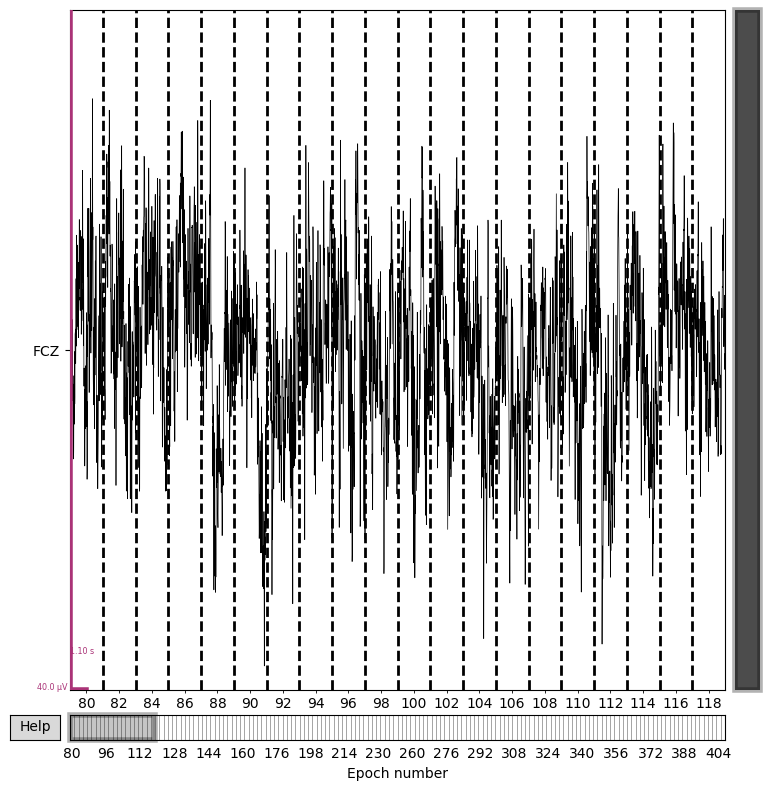

In [7]:
erp = mne.read_epochs(EEG_PROCESSED_DIR / '21101_epo.fif')
erp.plot(picks=['FCZ']);

In [8]:
evoked_co = erp['12','13','14','15','16','17','18','19'].average()
evoked_in = erp['24','25','26','27','28','29','30','31'].average()

Need more than one channel to make topography for eeg. Disabling interactivity.


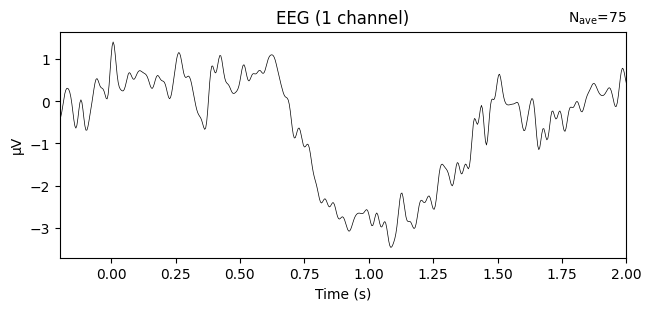

In [9]:
evoked_co.plot(picks=['FCZ']);

Need more than one channel to make topography for eeg. Disabling interactivity.


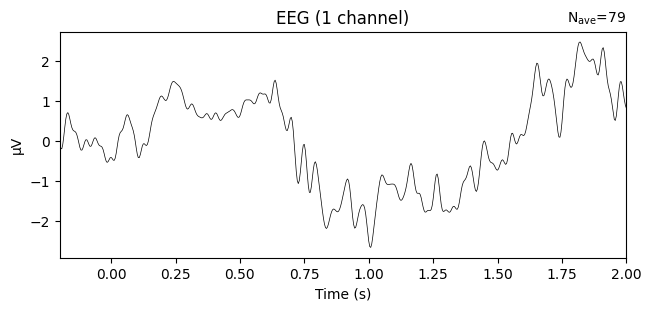

In [10]:
evoked_in.plot(picks=['FCZ']);